# Artificial Neural Network with TensorFlow

This notebook demonstrates how to load the MNIST dataset, preprocess the images, and build a simple Artificial Neural Network (ANN) using TensorFlow and Keras to classify handwritten digits.

In [9]:
# Importing the required libraries
from tensorflow import keras as ks
import matplotlib.pyplot as plt
import random
import numpy as np
import struct
from array import array
from os.path  import join

In [10]:
#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

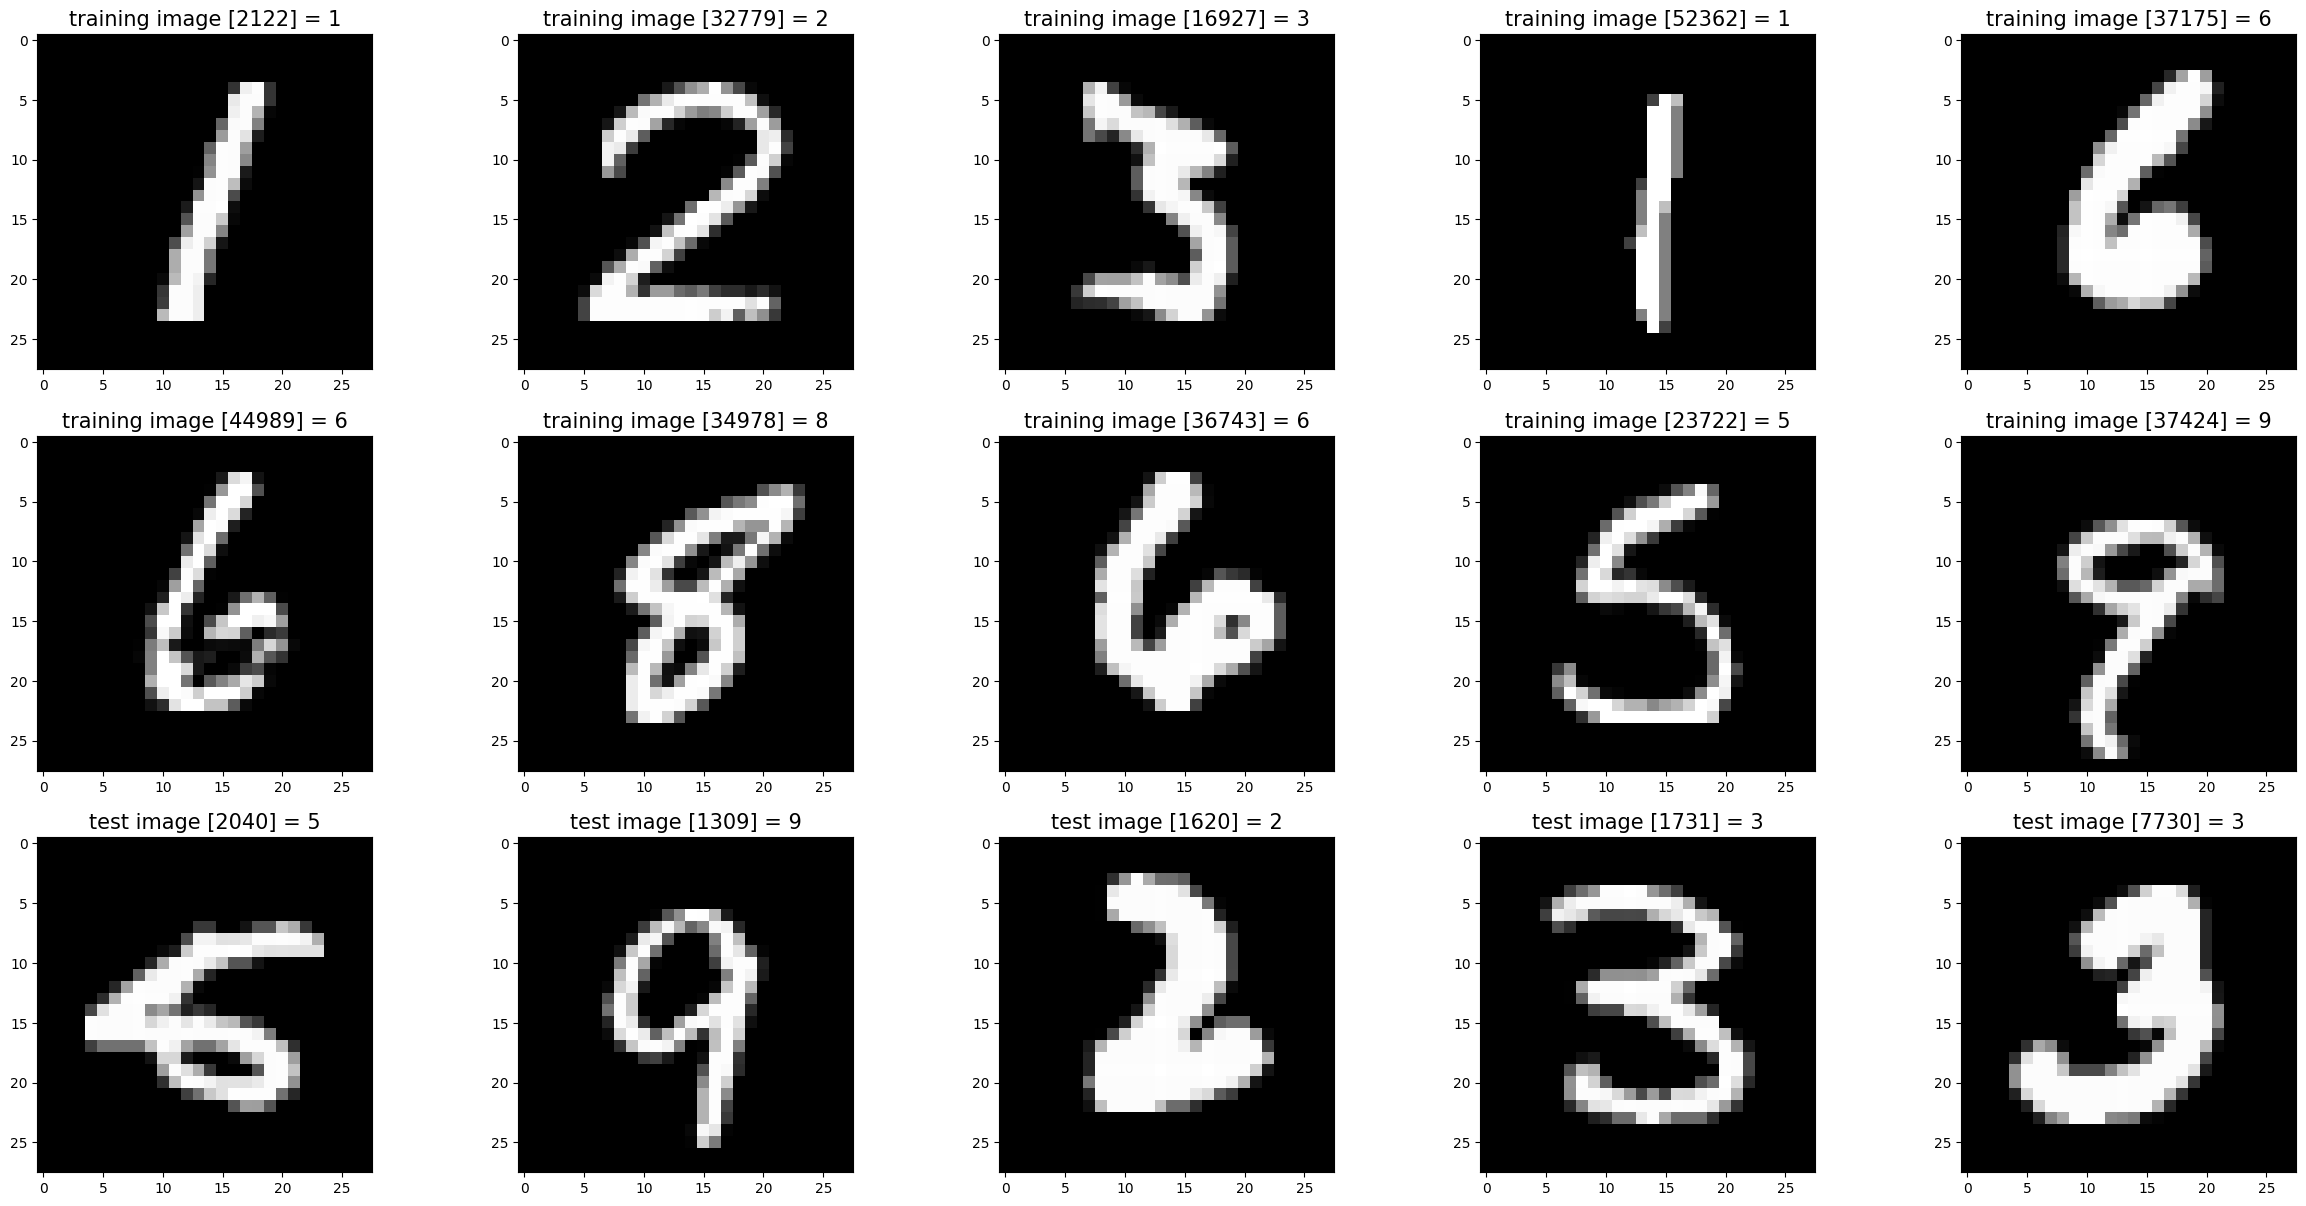

In [11]:
#
# Verify Reading Dataset via MnistDataloader class
#

#
# Set file paths based on added MNIST Datasets
#
input_path = ''
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)


In [12]:
# Preprocessing the data
# Pixel values range from 0 to 255. Scaled them down to 0.0 - 1.0 to help the network learn faster.
x_train = np.array(x_train) / 255.0
x_test = np.array(x_test) / 255.0
y_train = np.array(y_train)
y_test = np.array(y_test)


In [13]:
# Building the Neural Network
model = ks.models.Sequential([
  # Flatten the 28x28 image into a 1D array of 784 pixels
  ks.layers.Flatten(input_shape=(28, 28)),
  
  # Hidden layer: 128 neurons (this is where the "thinking" happens)
  ks.layers.Dense(128, activation='relu'),

  # Output layer: 10 neurons (one for each digit 0-9). 
  # 'softmax' is used to get a percentage probability for each digit.
  ks.layers.Dense(10, activation='softmax')
])

/home/indubrata/TechFiles/TDA_Bootcamp/MLDL/AritificialNeuralNetwork/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# Compiling the model
# Defining how the model measures its mistakes (loss) and how it updates itself (optimizer)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
# Training the model
print("Training the model...")
model.fit(x_train, y_train, epochs=5)

Training the model...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 964us/step - accuracy: 0.9245 - loss: 0.2619
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 973us/step - accuracy: 0.9665 - loss: 0.1136
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step - accuracy: 0.9757 - loss: 0.0791
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.9815 - loss: 0.0591
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 971us/step - accuracy: 0.9863 - loss: 0.0456


In [16]:
# Evaluating the model on the test data
print("\nEvaluating the model...")
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Evaluating the model...
313/313 - 0s - 872us/step - accuracy: 0.9768 - loss: 0.0775
Test Accuracy: 97.68%


# Deep Learning Core Concepts 

Based on the topics covered in the short version resources, here is a breakdown of the foundational concepts you need to understand to build your neural network.

### 1. The Basics of Neural Networks
***
At its core, an Artificial Neural Network (ANN) is a mathematical system inspired by the human brain. It consists of layers of interconnected nodes (neurons). 
* **Inputs:** The raw data fed into the network (e.g., the 784 pixels of an MNIST image).
* **Weights and Biases:** Each connection between neurons has a "weight" (how important that connection is), and each neuron has a "bias" (a baseline threshold). The network learns by continuously adjusting these weights and biases.
* **Hidden Layers:** The layers between the input and output where the network performs calculations to recognize patterns.

### 2. Activation Functions
***
If a neural network only multiplied weights and added biases, it would just be a giant linear regression model, entirely incapable of learning complex patterns like handwriting. 
* Activation functions introduce **non-linearity** into the network. 
* By applying an activation function (like ReLU, which converts all negative numbers to zero) to a neuron's output, the network gains the ability to map complex, non-linear relationships between the input images and their correct labels.

### 3. Multiple Inputs and Outputs
***
Real-world problems rarely involve a single input mapped to a single output.
* **Multiple Inputs:** In your MNIST task, a single image is not one input; it is an array of 784 distinct pixel values fed into the network simultaneously as a vector.
* **Multiple Outputs:** Because you are trying to classify 10 different digits (0 through 9), your final layer must have 10 output neurons, each representing the network's confidence for a specific digit.

### 4. Softmax and Argmax
***
When dealing with multiple outputs in classification, the raw numbers (logits) produced by the final layer are usually unscaled and difficult to interpret.
* **Softmax:** This function takes those raw output numbers and converts them into a probability distribution. The formula for the Softmax function is $\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$. It ensures that every output is between 0 and 1, and that all 10 outputs sum exactly to 1 (or 100%).
* **Argmax:** Once you have 10 probabilities, the `argmax` mathematical operation simply looks at the array and returns the **index** of the highest value. If the 3rd neuron has the highest probability (e.g., 98%), `argmax` tells the code that the network's final prediction is the digit "2" (since index 0 is digit 0).

### 5. Cross-Entropy Loss
***
For a network to learn, it must be able to quantify exactly how "wrong" its predictions are.
* **Cross-Entropy** is the standard loss function for classification tasks. It compares the predicted probability distribution (from the Softmax layer) against the true distribution (the actual label).
* The formula is $L = -\sum y_i \log(\hat{y}_i)$. If the network predicts a 99% probability for the correct digit, the cross-entropy loss is very close to zero. If it predicts a 1% probability for the correct digit, the loss penalty is massive.

### 6. Backpropagation (Backprop)
***
This is the engine of machine learning. Backpropagation is the algorithm used to minimize the Cross-Entropy loss

### 7. Backpropagation with Cross-Entropy
***
While we looked at Cross-Entropy (the loss function) and Backpropagation (the updating algorithm) separately, they are almost always used together in classification tasks because they create a mathematical synergy. 

Here is why they are the perfect pair:

* **The Goal:** When the network makes a mistake, backpropagation needs to calculate the "gradient" (the slope or derivative) of the Cross-Entropy loss to figure out how to adjust the weights. 
* **The Math Problem:** Calculating derivatives through multiple layers of a neural network can get incredibly messy and computationally expensive.
* **The Elegant Solution:** When you pair **Cross-Entropy loss** with a **Softmax output layer**, a mathematical cancellation happens during backpropagation. The complex derivative equations simplify down to a very clean, simple subtraction: `Prediction - Actual Label`. 

Because this combined math is so simple and computationally cheap to run, the network can calculate its errors and update its weights extremely fast. This specific pairing is what makes training modern classification networks efficient and possible.